# Mutual Fund Analytics
## Exploratory Data Analysis (EDA)

**Prepared by:** Monish

This notebook documents the EDA performed on the cleaned mutual fund datasets.

## Project Objective
Perform exploratory data analysis on the cleaned datasets using Python visualizations to understand NAV trends, AUM growth, SIP trends, investor demographics, portfolio allocation and other business insights.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully")

## NAV Trend Analysis

In [2]:
#  nav_trend_analysis.py

import pandas as pd
import plotly.express as px

file_path = r"D:\Mutual_Fund_Analytics\data\processed\02_nav_history_clean.csv"
df = pd.read_csv(file_path)

df["date"] = pd.to_datetime(df["date"])

df = df[
    (df["date"] >= "2022-01-01") &
    (df["date"] <= "2026-12-31")
]

df["amfi_code"] = df["amfi_code"].astype(str)

fig = px.line(
    df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend - All 40 Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "amfi_code": "AMFI Code"
    },
    template="plotly_white",
    height=700
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Corrections",
    annotation_position="top left"
)

fig.update_layout(

    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    legend_title="AMFI Code",
    hovermode="x unified"
)

fig.show()

**Insight 1:** Most mutual fund schemes showed a steady increase in NAV between 2022 and 2026 despite temporary corrections.

**Supporting Chart:** NAV Trend Analysis

## AUM Growth Analysis

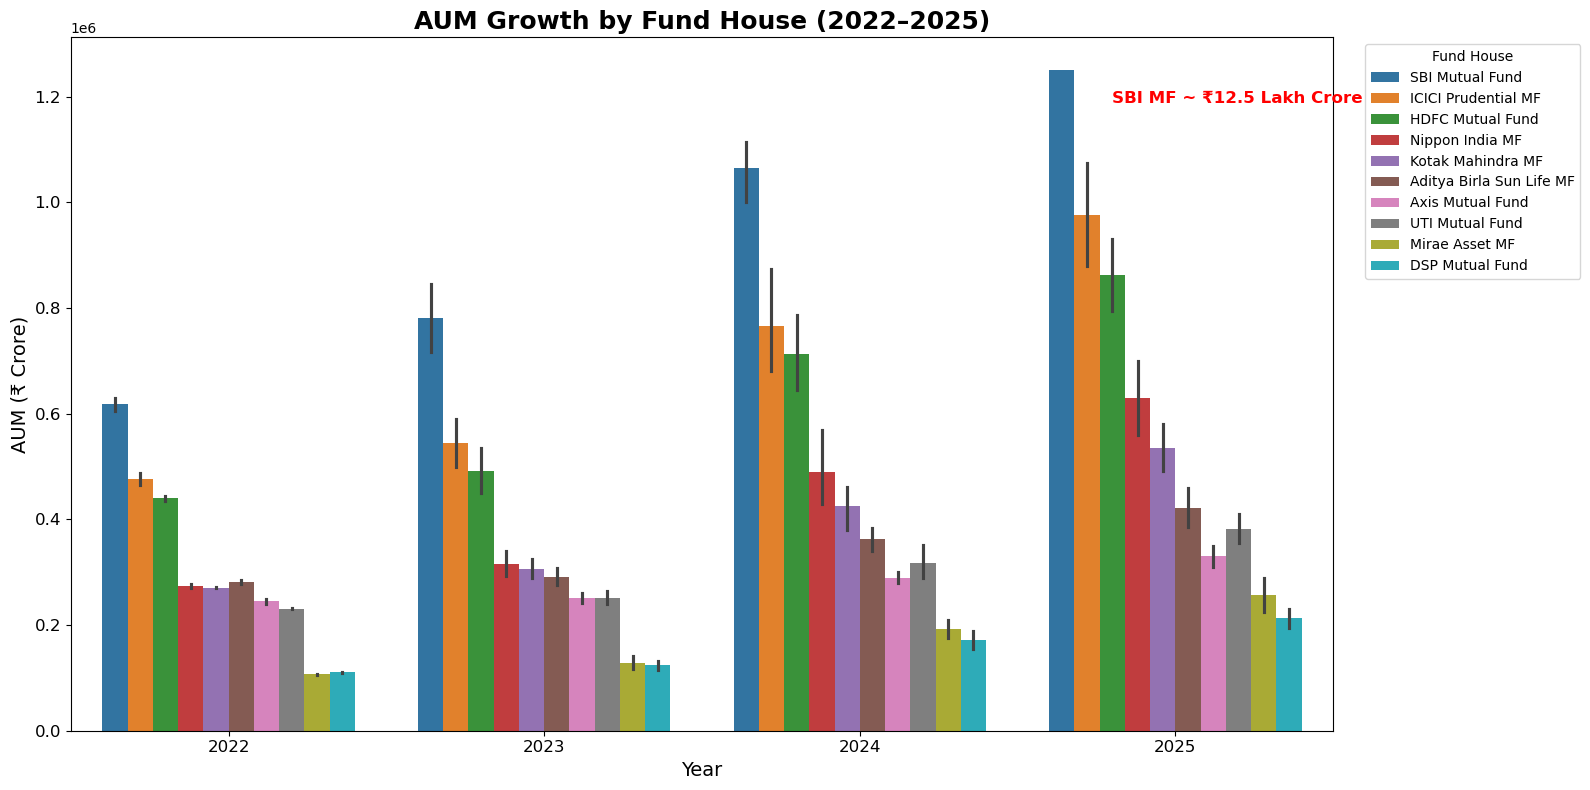

In [3]:
#  **aum_growth_analysis.py** 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\03_aum_by_fund_house_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Convert Date Column to DateTime
# ---------------------------------

df["date"] = pd.to_datetime(df["date"])

# ---------------------------------
# Extract Year
# ---------------------------------

df["year"] = df["date"].dt.year

# ---------------------------------
# Filter Years (2022–2025)
# ---------------------------------

df = df[
    (df["year"] >= 2022) &
    (df["year"] <= 2025)
]

# ---------------------------------
# Create Plot
# ---------------------------------

plt.figure(figsize=(16,8))

sns.barplot(
    data=df,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

# ---------------------------------
# Titles and Labels
# ---------------------------------

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=14)

plt.ylabel("AUM (₹ Crore)", fontsize=14)

plt.xticks(fontsize=12)

plt.yticks(fontsize=12)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# ---------------------------------
# Highlight SBI Dominance
# ---------------------------------

plt.text(
    2.8,
    df["aum_crore"].max()*0.95,
    "SBI MF ~ ₹12.5 Lakh Crore",
    fontsize=12,
    color="red",
    fontweight="bold"
)

plt.tight_layout()

plt.show()

**Insight 2:** SBI Mutual Fund maintained the highest AUM among all fund houses.

**Supporting Chart:** AUM Growth Bar Chart

## Monthly SIP Inflow Analysis

In [4]:
#  **sip_inflow_analysis.py** 

import pandas as pd
import plotly.express as px

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\04_monthly_sip_inflows_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Convert Month Column to DateTime
# ---------------------------------

df["month"] = pd.to_datetime(df["month"])

# ---------------------------------
# Filter Data (Jan 2022 – Dec 2025)
# ---------------------------------

df = df[
    (df["month"] >= "2022-01-01") &
    (df["month"] <= "2025-12-31")
]

# ---------------------------------
# Create Interactive Line Chart
# ---------------------------------

fig = px.line(
    df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    template="plotly_white",
    height=650
)

# ---------------------------------
# Highlight Highest SIP Inflow
# ---------------------------------

max_row = df.loc[df["sip_inflow_crore"].idxmax()]

fig.add_scatter(
    x=[max_row["month"]],
    y=[max_row["sip_inflow_crore"]],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=["₹31,002 Cr\nDec 2025"],
    textposition="top center",
    showlegend=False
)

# ---------------------------------
# Improve Layout
# ---------------------------------

fig.update_layout(
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified"
)

# ---------------------------------
# Display Chart
# ---------------------------------

fig.show()

**Insight 3:** SIP inflows increased steadily and reached approximately ₹31,002 Cr in Dec 2025.

**Supporting Chart:** Monthly SIP Inflow Time-Series

## Category Inflow Heatmap

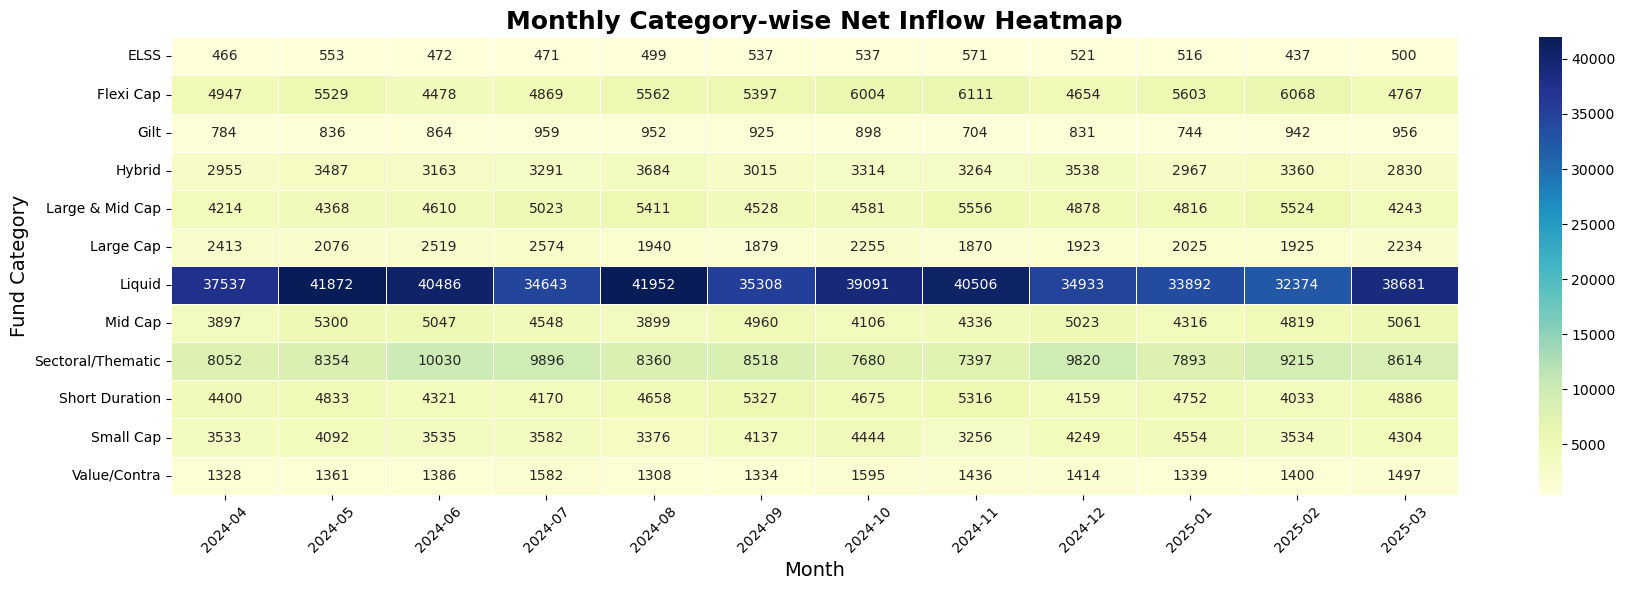

In [5]:
#  **category_inflow_heatmap.py** 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\05_category_inflows_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Convert Month Column to DateTime
# ---------------------------------

df["month"] = pd.to_datetime(df["month"])

# ---------------------------------
# Convert Month to Year-Month Format
# ---------------------------------

df["month"] = df["month"].dt.strftime("%Y-%m")

# ---------------------------------
# Create Pivot Table
# ---------------------------------

heatmap_data = df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# ---------------------------------
# Plot Heatmap
# ---------------------------------

plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

# ---------------------------------
# Chart Title and Labels
# ---------------------------------

plt.title(
    "Monthly Category-wise Net Inflow Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=14)

plt.ylabel("Fund Category", fontsize=14)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Insight 4:** Equity-oriented categories attracted the highest inflows in most months.

**Supporting Chart:** Category Inflow Heatmap

## Investor Demographics

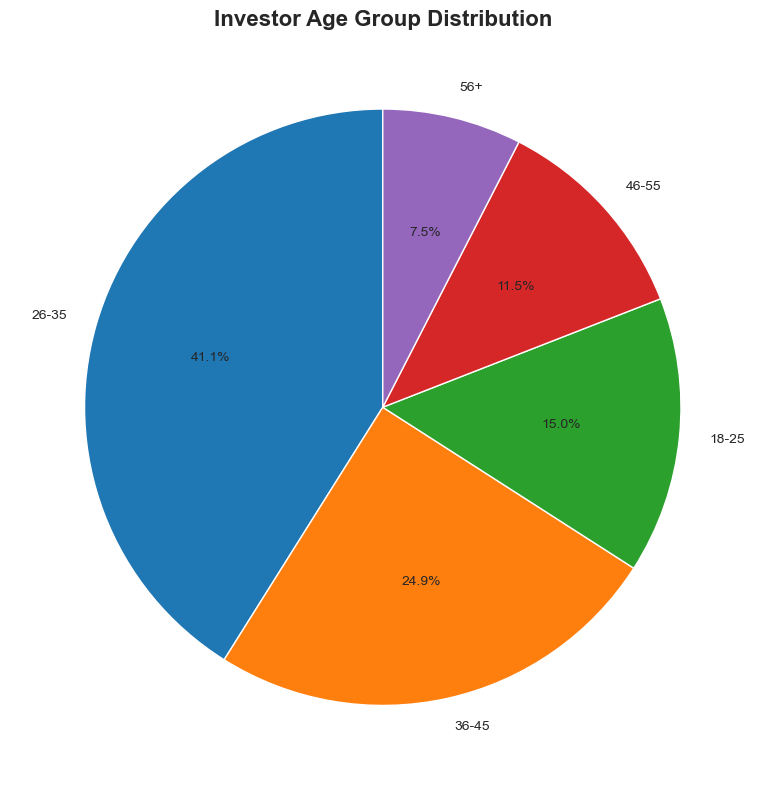

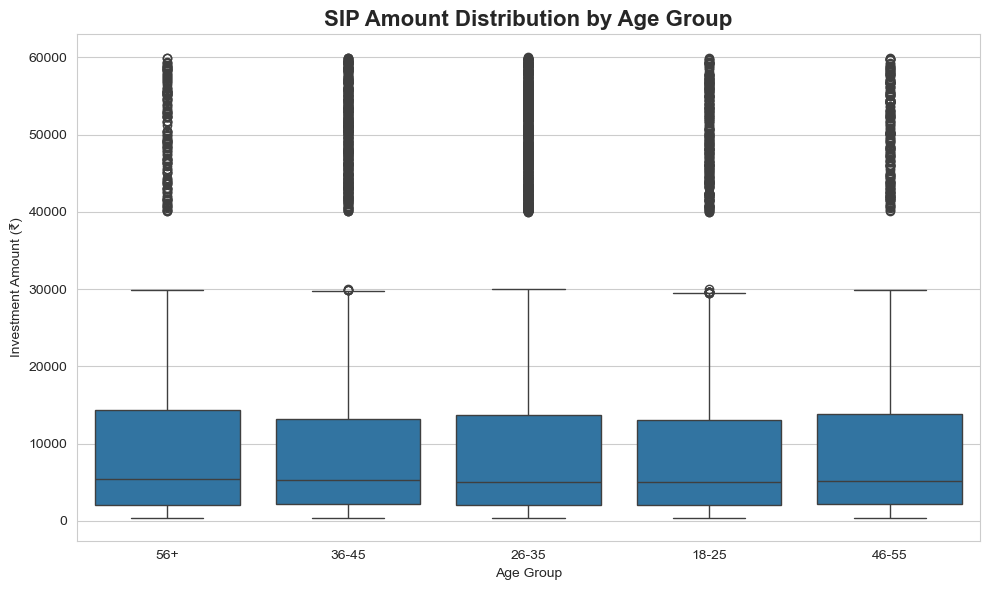

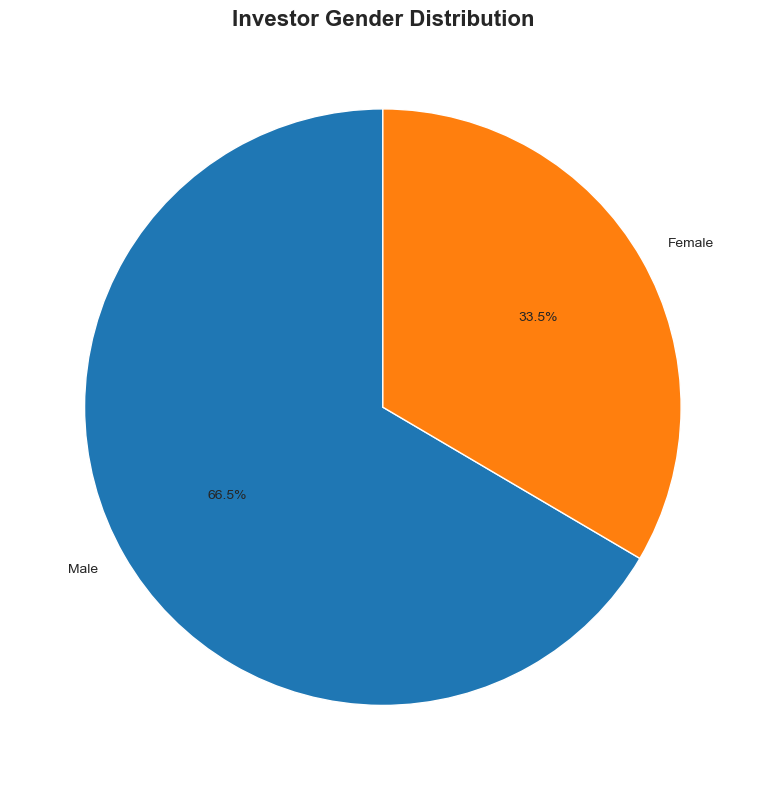

In [6]:
# investor_demographics.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\08_investor_transactions_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Set Plot Style
# ---------------------------------

sns.set_style("whitegrid")

# ======================================================
# 1. Age Group Distribution (Pie Chart)
# ======================================================

plt.figure(figsize=(8,8))

age_counts = df["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ======================================================
# 2. SIP Amount by Age Group (Box Plot)
# ======================================================

plt.figure(figsize=(10,6))

sip_df = df[df["transaction_type"] == "SIP"]

sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.tight_layout()
plt.show()

# ======================================================
# 3. Gender Distribution (Pie Chart)
# ======================================================

plt.figure(figsize=(8,8))

gender_counts = df["gender"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Gender Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Insight 5:** Working-age investors form the largest investor segment.

**Supporting Chart:** Age Distribution / SIP Box Plot / Gender Split

## Geographic Distribution

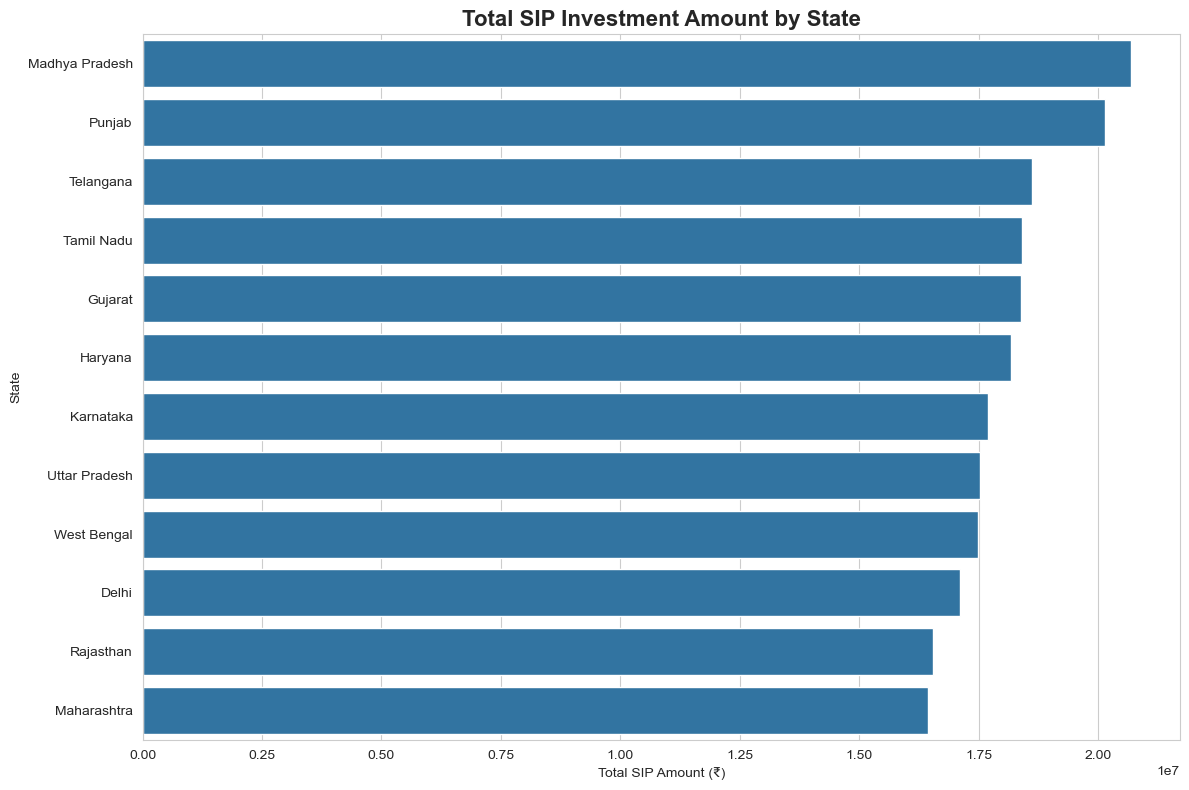

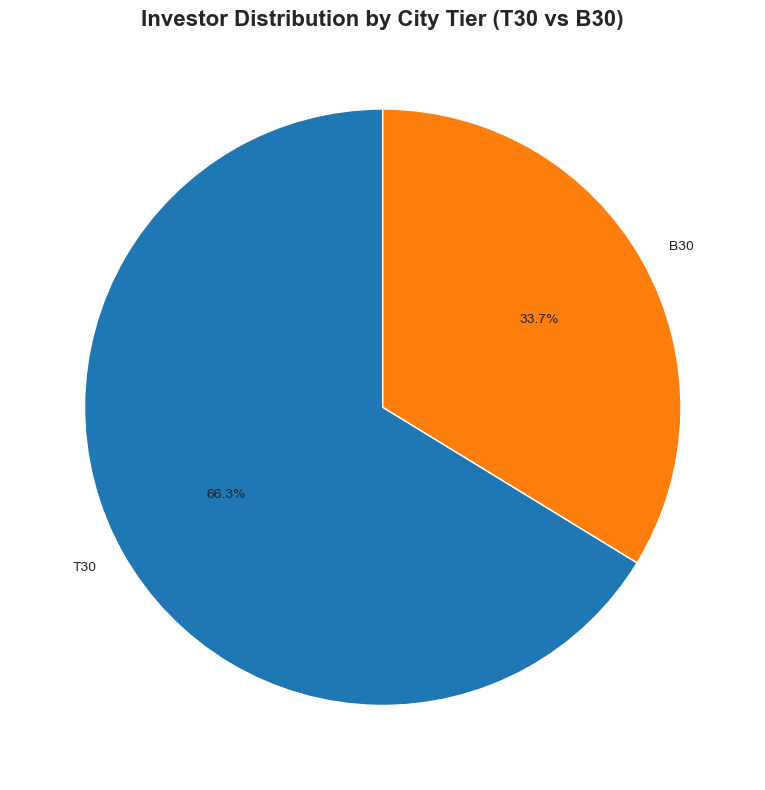

In [7]:
# geographic_distribution.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\08_investor_transactions_clean.csv"

df = pd.read_csv(file_path)

sns.set_style("whitegrid")

# ======================================================
# 1. Horizontal Bar Chart - SIP Amount by State
# ======================================================

sip_df = df[df["transaction_type"] == "SIP"]

state_sip = (
    sip_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title(
    "Total SIP Investment Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total SIP Amount (₹)")

plt.ylabel("State")

plt.tight_layout()

plt.show()

# ======================================================
# 2. T30 vs B30 City Tier Pie Chart
# ======================================================

plt.figure(figsize=(8,8))

city_tier = df["city_tier"].value_counts()

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Distribution by City Tier (T30 vs B30)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

**Insight 6:** A few states contribute a major share of SIP investments, with participation from both T30 and B30 cities.

**Supporting Chart:** Geographic Distribution

## Folio Count Growth

In [8]:
# folio_growth_analysis.py

import pandas as pd
import plotly.express as px

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\06_industry_folio_count_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Convert Month to DateTime
# ---------------------------------

df["month"] = pd.to_datetime(df["month"])

# ---------------------------------
# Filter Data (2022–2025)
# ---------------------------------

df = df[
    (df["month"] >= "2022-01-01") &
    (df["month"] <= "2025-12-31")
]

# ---------------------------------
# Create Line Chart
# ---------------------------------

fig = px.line(
    df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth of Mutual Fund Folios (2022–2025)",
    labels={
        "month":"Month",
        "total_folios_crore":"Total Folios (Crore)"
    },
    template="plotly_white",
    height=650
)

# ---------------------------------
# Mark January 2022
# ---------------------------------

fig.add_scatter(
    x=[df.iloc[0]["month"]],
    y=[df.iloc[0]["total_folios_crore"]],
    mode="markers+text",
    marker=dict(size=12, color="green"),
    text=["13.26 Cr\nJan 2022"],
    textposition="bottom right",
    showlegend=False
)

# ---------------------------------
# Mark December 2025
# ---------------------------------

fig.add_scatter(
    x=[df.iloc[-1]["month"]],
    y=[df.iloc[-1]["total_folios_crore"]],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=["26.12 Cr\nDec 2025"],
    textposition="top left",
    showlegend=False
)

# ---------------------------------
# Improve Layout
# ---------------------------------

fig.update_layout(
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    hovermode="x unified"
)

# ---------------------------------
# Display Chart
# ---------------------------------

fig.show()

**Insight 7:** Mutual fund folios grew consistently from 13.26 Cr to 26.12 Cr.

**Supporting Chart:** Folio Growth

## NAV Return Correlation

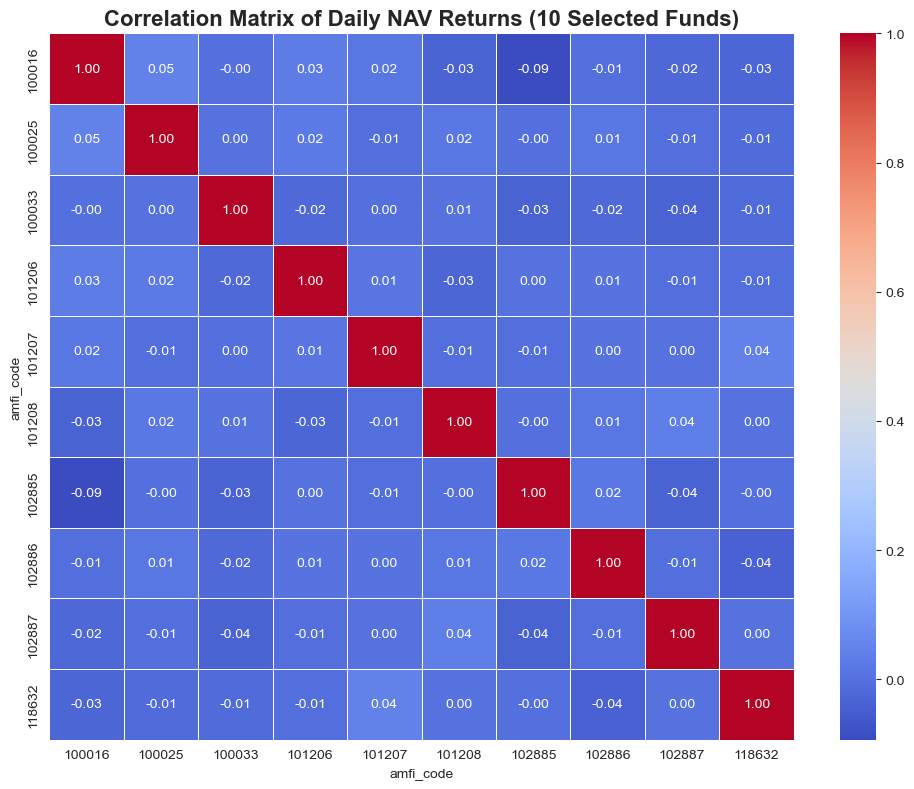

In [9]:
# nav_return_correlation.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\02_nav_history_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Convert Date Column
# ---------------------------------

df["date"] = pd.to_datetime(df["date"])

# ---------------------------------
# Select First 10 Mutual Funds
# ---------------------------------

selected_funds = df["amfi_code"].unique()[:10]

df = df[df["amfi_code"].isin(selected_funds)]

# ---------------------------------
# Pivot NAV Data
# ---------------------------------

pivot_df = df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# ---------------------------------
# Calculate Daily Returns
# ---------------------------------

daily_returns = pivot_df.pct_change().dropna()

# ---------------------------------
# Correlation Matrix
# ---------------------------------

correlation_matrix = daily_returns.corr()

# ---------------------------------
# Plot Heatmap
# ---------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily NAV Returns (10 Selected Funds)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

**Insight 8:** Several selected funds show strong positive return correlation.

**Supporting Chart:** Correlation Heatmap

## Sector Allocation

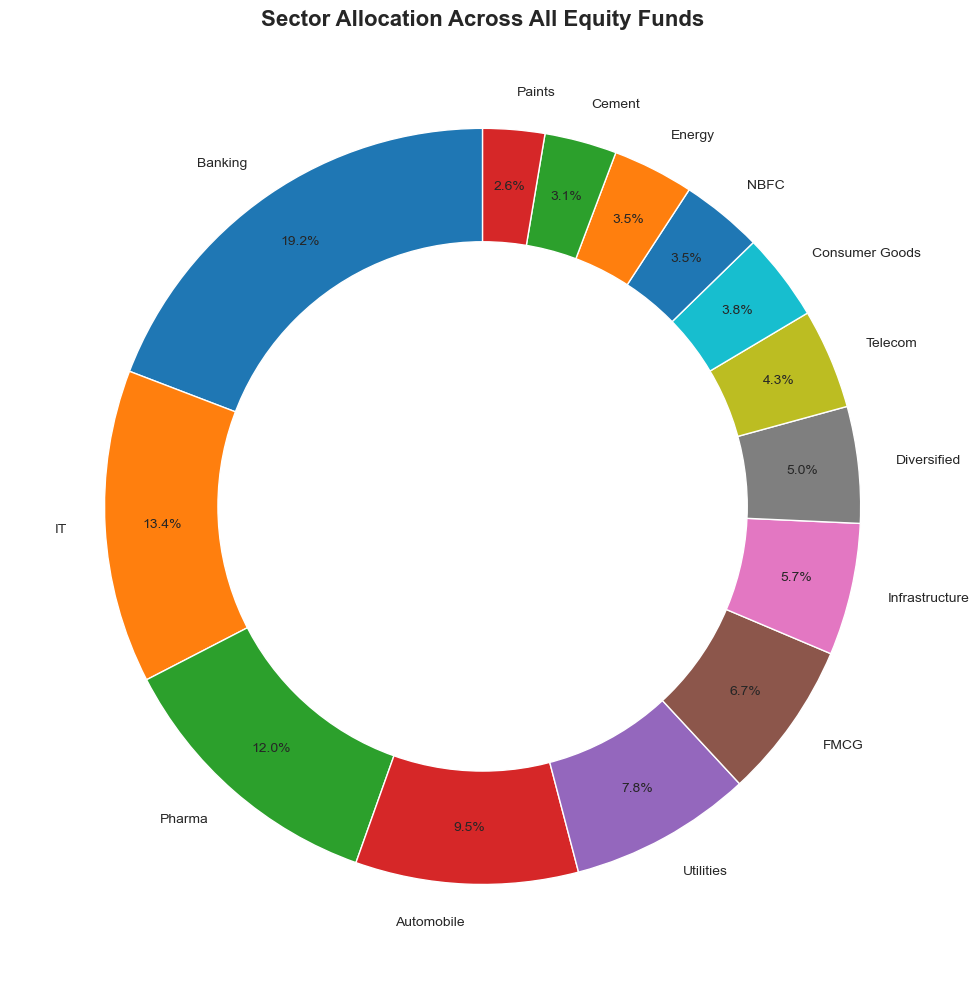

In [10]:
# sector_allocation.py

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# Load Cleaned Dataset
# ---------------------------------

file_path = r"D:\Mutual_Fund_Analytics\data\processed\09_portfolio_holdings_clean.csv"

df = pd.read_csv(file_path)

# ---------------------------------
# Aggregate Sector Weights
# ---------------------------------

sector_weights = (
    df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# ---------------------------------
# Create Donut Chart
# ---------------------------------

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

# Create Donut Hole
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

# ---------------------------------
# Chart Title
# ---------------------------------

plt.title(
    "Sector Allocation Across All Equity Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

**Insight 9:** Portfolio allocation is diversified across sectors, with a few sectors dominating overall weight.

**Supporting Chart:** Sector Allocation Donut

## Insight 10

**Finding:** The combined EDA indicates strong industry growth, rising investor participation, increasing SIP inflows, and healthy diversification across mutual fund portfolios.

**Supporting Charts:** Overall EDA Dashboard


# Conclusion

The exploratory data analysis demonstrates positive growth in the Indian mutual fund industry. The notebook combines data preparation, visualization, and business insights, providing a strong foundation for dashboard development and further analytics.
